In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import root_mean_squared_error, r2_score 

Loading the external prepared dataset.

In [2]:

df_fossil_fuel = pd.read_csv('../datasets/prepared_data/fossil_fuel_production_by_country_year.csv')
df_fossil_fuel


,country,iso3,Year,coal_production_twh,oil_production_twh,gas_production_twh,total_production_twh
0,Algeria,DZA,1965,NaN,304.00020,NaN,304.000200
1,Algeria,DZA,1966,NaN,391.26200,NaN,391.262000
2,Algeria,DZA,1967,NaN,449.44415,NaN,449.444150
3,Algeria,DZA,1968,NaN,493.38818,NaN,493.388180
4,Algeria,DZA,1969,NaN,516.78827,NaN,516.788270
...,...,...,...,...,...,...,...
3783,Zimbabwe,ZWE,2021,24.290953,NaN,NaN,24.290953
3784,Zimbabwe,ZWE,2022,29.553642,NaN,NaN,29.553642
3785,Zimbabwe,ZWE,2023,37.412743,NaN,NaN,37.412743
3786,Zimbabwe,ZWE,2024,43.476120,NaN,NaN,43.476120


Dropping the NaN values for total_production_twh

In [3]:
df_clean = df_fossil_fuel.dropna(subset=['total_production_twh'])
df_clean

,country,iso3,Year,coal_production_twh,oil_production_twh,gas_production_twh,total_production_twh
0,Algeria,DZA,1965,NaN,304.00020,NaN,304.000200
1,Algeria,DZA,1966,NaN,391.26200,NaN,391.262000
2,Algeria,DZA,1967,NaN,449.44415,NaN,449.444150
3,Algeria,DZA,1968,NaN,493.38818,NaN,493.388180
4,Algeria,DZA,1969,NaN,516.78827,NaN,516.788270
...,...,...,...,...,...,...,...
3783,Zimbabwe,ZWE,2021,24.290953,NaN,NaN,24.290953
3784,Zimbabwe,ZWE,2022,29.553642,NaN,NaN,29.553642
3785,Zimbabwe,ZWE,2023,37.412743,NaN,NaN,37.412743
3786,Zimbabwe,ZWE,2024,43.476120,NaN,NaN,43.476120


Creating a new column for year-to-year production change

In [4]:
df_clean['Production change'] = df_clean.groupby('iso3')['total_production_twh'].pct_change()
df_clean.dropna(subset=['Production change'], inplace=True)
df_clean

,country,iso3,Year,coal_production_twh,oil_production_twh,gas_production_twh,total_production_twh,Production change
1,Algeria,DZA,1966,NaN,391.26200,NaN,391.262000,0.287045
2,Algeria,DZA,1967,NaN,449.44415,NaN,449.444150,0.148704
3,Algeria,DZA,1968,NaN,493.38818,NaN,493.388180,0.097774
4,Algeria,DZA,1969,NaN,516.78827,NaN,516.788270,0.047427
5,Algeria,DZA,1970,NaN,561.88590,24.380125,586.266025,0.134441
...,...,...,...,...,...,...,...,...
3783,Zimbabwe,ZWE,2021,24.290953,NaN,NaN,24.290953,0.197078
3784,Zimbabwe,ZWE,2022,29.553642,NaN,NaN,29.553642,0.216652
3785,Zimbabwe,ZWE,2023,37.412743,NaN,NaN,37.412743,0.265927
3786,Zimbabwe,ZWE,2024,43.476120,NaN,NaN,43.476120,0.162067


The first value becomes NaN since there is no previous year to compare to

In [5]:
df_clean['Production change'].describe()

/opt/anaconda3/envs/fofds/lib/python3.12/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    3715.000000
mean             inf
std              NaN
min        -1.000000
25%        -0.033321
50%         0.016488
75%         0.075668
max              inf
Name: Production change, dtype: float64

Cleaning up the the new column Production change

In [6]:
print(np.isnan(df_clean['Production change']).sum())
print(np.isinf(df_clean['Production change']).sum())
df_clean['Production change'] = df_clean['Production change'].replace([np.inf, -np.inf], np.nan)
print(df_clean['Production change'].describe())

0
1
count    3714.000000
mean        0.175959
std         3.308401
min        -1.000000
25%        -0.033324
50%         0.016464
75%         0.075645
max       145.766734
Name: Production change, dtype: float64


Some values are extreme (a country goes from having no export one year to suddenly having another year), which will affect the squared error so we clip using the 1st and 99th
precentiles. They aren't removed just capped to a reasonable bound.

In [7]:
# Clipping the extreme values by setting a threshold based on the precentiles
lower = df_clean['Production change'].quantile(0.01)
upper = df_clean['Production change'].quantile(0.99)
df_clean['Production change'] = df_clean['Production change'].clip(lower, upper)
df_clean = df_clean.dropna(subset=['Production change'])
print(np.isnan(df_clean['Production change']).sum())
df_clean['Production change'].describe()


0


count    3714.000000
mean        0.047568
std         0.218677
min        -0.371272
25%        -0.033324
50%         0.016464
75%         0.075645
max         1.505071
Name: Production change, dtype: float64

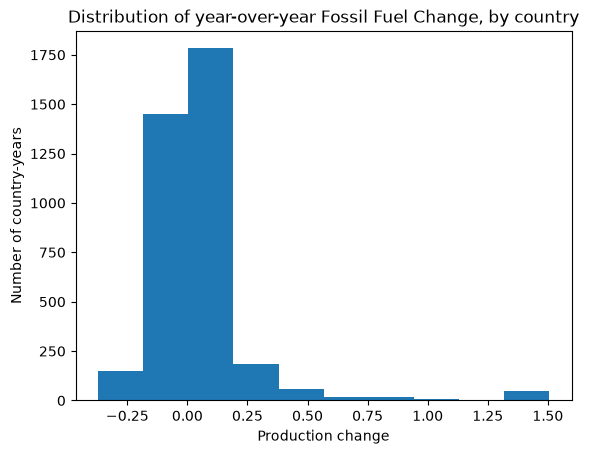

In [8]:
fig, ax = plt.subplots()

data_prod_change = df_clean['Production change']

ax.hist(data_prod_change)
ax.set_xlabel('Production change')
ax.set_ylabel('Number of country-years')
ax.set_title('Distribution of year-over-year Fossil Fuel Change, by country')

plt.show()

# The isolated bar represents represents values capped at the 99th precentile 

Importing the major exporters as well as the transition talk score for prediction

In [9]:
df_major_exporters = pd.read_csv('../datasets/prepared_data/major_exporters.csv')
df_clean = df_clean.merge(df_major_exporters[['iso3', 'Is exporter']], how="left", on='iso3')

In [10]:
df_simple = pd.read_parquet('../datasets/speeches_simple_clean.parquet')[['WordCount']]
df_advanced = pd.read_parquet('../datasets/speeches_advanced_clean.parquet')

df_speech = df_advanced.join(df_simple, how='left')

df_speech['mention_rate'] = df_speech['transition_mention_count'] / df_speech['WordCount']
df_speech['net_caution'] = df_speech['word15_net_caution'].fillna(0)

df_speech = df_speech.reset_index().rename(columns={'ISO-alpha3 Code': 'iso3'})
df_speech[['iso3', 'Year', 'mention_rate', 'net_caution']].describe()

,Year,mention_rate,net_caution
count,2128.000000,2128.000000,2128.000000
mean,2019.980263,0.000334,-0.011632
std,3.156114,0.000681,0.125824
min,2015.000000,0.000000,-2.000000
25%,2017.000000,0.000000,0.000000
50%,2020.000000,0.000000,0.000000
75%,2023.000000,0.000483,0.000000
max,2025.000000,0.007816,1.000000


In [11]:
df_clean = df_clean.merge(df_speech[['iso3', 'Year', 'mention_rate', 'net_caution']],
                          how='inner', on=['iso3', 'Year'])
df_clean['mention_rate_for_exporter'] = df_clean['mention_rate'] * df_clean['Is exporter']
df_clean['net_caution_for_exporter'] = df_clean['net_caution'] * df_clean['Is exporter']
print(df_clean.shape)

(787, 13)


Creating a column for transition talk score only for big exporters and fitting the model

In [12]:
X = df_clean[['Is exporter', 'mention_rate', 'net_caution', 
              'mention_rate_for_exporter', 'net_caution_for_exporter']].astype(float)
Y = df_clean['Production change']

years = sorted(df_clean['Year'].unique())
cutoff = years[int(len(years) * 0.8)]

train_mask = df_clean['Year'] < cutoff
test_mask = df_clean['Year'] >= cutoff 

X_train, X_test = X[train_mask], X[test_mask]
Y_train, Y_test = Y[train_mask], Y[test_mask]

X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

model = sm.OLS(Y_train, X_train).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:      Production change   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.136
Date:                Wed, 23 Sep 2026   Prob (F-statistic):              0.340
Time:                        20:07:54   Log-Likelihood:                 256.27
No. Observations:                 572   AIC:                            -500.5
Df Residuals:                     566   BIC:                            -474.4
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

Predicting the production change.

In [13]:
Y_pred = model.predict(X_test)

mse = root_mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f"Test Mean Squared Error: {mse:.4f}")
print(f"Test R^2: {r2:.4f}")

Test Mean Squared Error: 0.1528
Test R^2: 0.0201
